<a href="https://colab.research.google.com/github/emanfalak53-creator/Artifical-Neural-Network-lab-/blob/main/ANN_Lab_03_Perceptron_Weight_Initialization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANN Lab 03 — Perceptron & Weight Initialization

**Tasks 1–9:** Dataset loading/visualization, perceptron from scratch, learning curves, and Gaussian, Xavier, He, and Orthogonal initialization.

This notebook uses:
- **Dataset 1:** Breast Cancer Wisconsin (Diagnostic) — binary classification
- **Dataset 2:** Breast Cancer Wisconsin (Diagnostic), a different train/test experimental split for Task 9

The perceptron is implemented **from scratch using NumPy**. No built-in Perceptron classifier is used.


In [2]:
# Task 1 — Imports and dataset loading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset shape:", X.shape)
print("\nFeatures:")
print(list(X.columns))
print("\nTarget classes:", np.unique(y))
print("Class names:", list(data.target_names))
print("\nMissing values:", X.isnull().sum().sum())
print("\nClass distribution:")
print(y.value_counts().sort_index())


Dataset shape: (569, 30)

Features:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Target classes: [0 1]
Class names: [np.str_('malignant'), np.str_('benign')]

Missing values: 0

Class distribution:
target
0    212
1    357
Name: count, dtype: int64


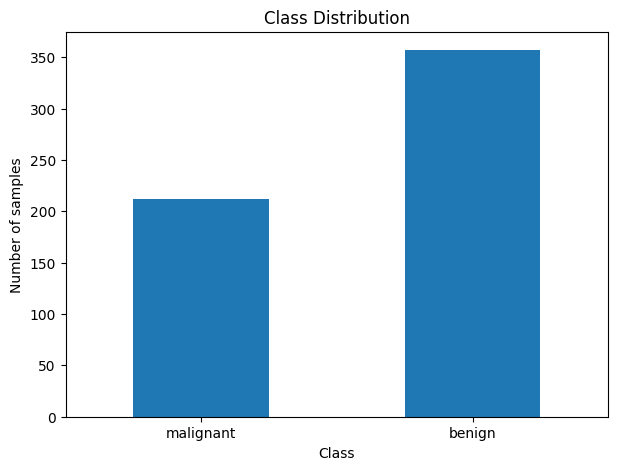

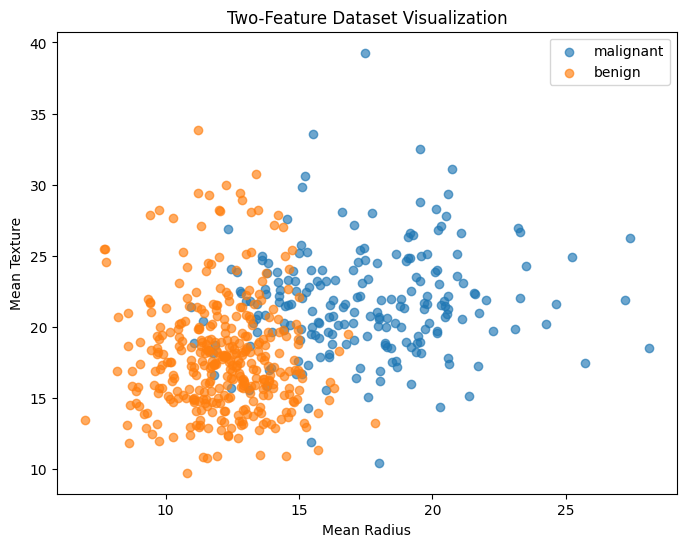

In [3]:
# Task 1 — Basic visualization
plt.figure(figsize=(7,5))
y.value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], data.target_names, rotation=0)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Class Distribution")
plt.show()

# Visualize two features
plt.figure(figsize=(8,6))
for cls in [0, 1]:
    idx = y == cls
    plt.scatter(X.loc[idx, "mean radius"],
                X.loc[idx, "mean texture"],
                label=data.target_names[cls], alpha=0.65)
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Two-Feature Dataset Visualization")
plt.legend()
plt.show()


In [4]:
# Task 1 — Train/test split and feature scaling
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert labels from {0,1} to {-1,+1} for the perceptron update rule
y_train_pm = np.where(y_train == 0, -1, 1)
y_test_pm = np.where(y_test == 0, -1, 1)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (455, 30)
Testing shape: (114, 30)


## Task 2 — Perceptron From Scratch

For each sample:

**Activation / prediction**

`z = w · x + b`

`prediction = +1 if z >= 0 else -1`

**Update rule**

If the prediction is wrong:

`w = w + learning_rate × y × x`

`b = b + learning_rate × y`

The implementation below does not use `sklearn.linear_model.Perceptron`.


In [5]:
# Task 2 — Perceptron from scratch
class PerceptronScratch:
    def __init__(self, learning_rate=0.01, max_epochs=100, init_method="zero",
                 random_state=42, tol=0):
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.init_method = init_method
        self.random_state = random_state
        self.tol = tol
        self.w = None
        self.b = None
        self.errors_ = []
        self.converged_epoch_ = None

    def initialize_weights(self, n_features):
        rng = np.random.default_rng(self.random_state)

        if self.init_method == "zero":
            self.w = np.zeros(n_features)
        elif self.init_method == "random":
            self.w = rng.normal(0, 0.01, n_features)
        elif self.init_method == "gaussian":
            self.w = rng.normal(0, 0.1, n_features)
        elif self.init_method == "xavier":
            std = np.sqrt(2.0 / (n_features + 1))
            self.w = rng.normal(0, std, n_features)
        elif self.init_method == "he":
            std = np.sqrt(2.0 / n_features)
            self.w = rng.normal(0, std, n_features)
        elif self.init_method == "orthogonal":
            # For a single-output perceptron, generate a random vector and normalize it.
            v = rng.normal(size=n_features)
            self.w = v / np.linalg.norm(v)
        else:
            raise ValueError("Unknown initialization method")

        self.b = 0.0

    def predict(self, X):
        scores = X @ self.w + self.b
        return np.where(scores >= 0, 1, -1)

    def fit(self, X, y):
        self.initialize_weights(X.shape[1])
        self.errors_ = []
        self.converged_epoch_ = None

        for epoch in range(1, self.max_epochs + 1):
            errors = 0
            for xi, target in zip(X, y):
                pred = 1 if (np.dot(xi, self.w) + self.b) >= 0 else -1
                update = self.learning_rate * (target - pred) / 2

                if update != 0:
                    self.w += update * xi
                    self.b += update
                    errors += 1

            self.errors_.append(errors)

            if errors <= self.tol:
                self.converged_epoch_ = epoch
                break

        if self.converged_epoch_ is None:
            self.converged_epoch_ = self.max_epochs

        return self

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

# Default/random initialization
default_model = PerceptronScratch(
    learning_rate=0.01, max_epochs=100, init_method="random", random_state=42
)
default_model.fit(X_train, y_train_pm)

print("Final weights:", default_model.w)
print("Final bias:", default_model.b)
print("Test accuracy:", default_model.score(X_test, y_test_pm))
print("Epochs:", default_model.converged_epoch_)


Final weights: [-0.02444549  0.0435707  -0.01013879 -0.04880496 -0.05155718  0.3523042
 -0.14005373 -0.09657621  0.00980651 -0.11088715 -0.11034799  0.03190002
  0.09943347 -0.20671761 -0.03299963 -0.16634166  0.31142595 -0.1474236
  0.05220835  0.05812785 -0.09940013 -0.18307143 -0.01129455 -0.16972336
  0.00146387  0.04149786 -0.26380812 -0.01820608 -0.14505753  0.04779348]
Final bias: -0.04
Test accuracy: 0.9649122807017544
Epochs: 100


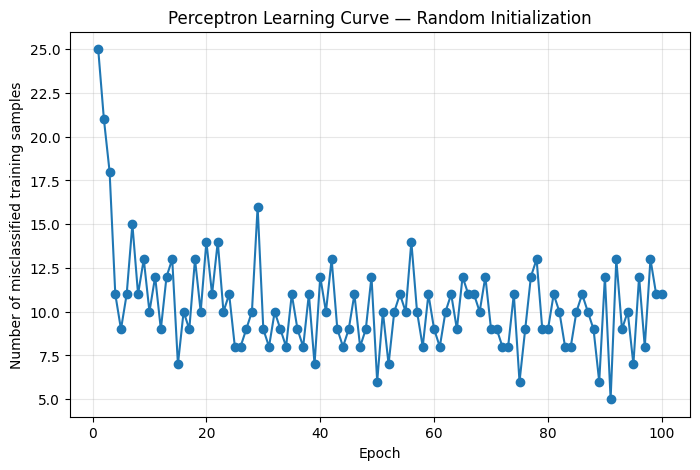

Final weights:
[-0.02444549  0.0435707  -0.01013879 -0.04880496 -0.05155718  0.3523042
 -0.14005373 -0.09657621  0.00980651 -0.11088715 -0.11034799  0.03190002
  0.09943347 -0.20671761 -0.03299963 -0.16634166  0.31142595 -0.1474236
  0.05220835  0.05812785 -0.09940013 -0.18307143 -0.01129455 -0.16972336
  0.00146387  0.04149786 -0.26380812 -0.01820608 -0.14505753  0.04779348]

Final bias: -0.04
Final training error: 11


In [6]:
# Task 3 — Learning curve
plt.figure(figsize=(8,5))
plt.plot(range(1, len(default_model.errors_) + 1), default_model.errors_, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Number of misclassified training samples")
plt.title("Perceptron Learning Curve — Random Initialization")
plt.grid(True, alpha=0.3)
plt.show()

print("Final weights:")
print(default_model.w)
print("\nFinal bias:", default_model.b)
print("Final training error:", default_model.errors_[-1])


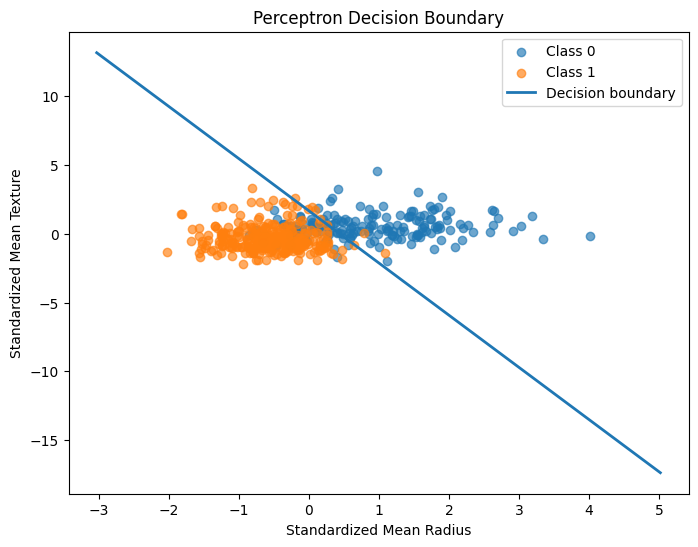

In [7]:
# Task 3 — Decision boundary using two selected features
# Train a 2-feature perceptron so the boundary can be plotted.
feature_cols = ["mean radius", "mean texture"]
X2 = X[feature_cols].values
y2 = y.values
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.20, random_state=42, stratify=y2
)
scaler2 = StandardScaler()
X2_train = scaler2.fit_transform(X2_train)
X2_test = scaler2.transform(X2_test)
y2_train_pm = np.where(y2_train == 0, -1, 1)
y2_test_pm = np.where(y2_test == 0, -1, 1)

model2 = PerceptronScratch(learning_rate=0.01, max_epochs=100, init_method="random", random_state=42)
model2.fit(X2_train, y2_train_pm)

plt.figure(figsize=(8,6))
for cls in [-1, 1]:
    idx = y2_train_pm == cls
    plt.scatter(X2_train[idx,0], X2_train[idx,1], alpha=0.65,
                label="Class 0" if cls == -1 else "Class 1")

x_min, x_max = X2_train[:,0].min()-1, X2_train[:,0].max()+1
xs = np.linspace(x_min, x_max, 200)

if abs(model2.w[1]) > 1e-12:
    ys = -(model2.w[0] * xs + model2.b) / model2.w[1]
    plt.plot(xs, ys, linewidth=2, label="Decision boundary")

plt.xlabel("Standardized Mean Radius")
plt.ylabel("Standardized Mean Texture")
plt.title("Perceptron Decision Boundary")
plt.legend()
plt.show()


## Tasks 4–7 — Initialization Methods

- **Gaussian:** weights sampled from `N(0, 0.1²)`
- **Xavier/Glorot:** standard deviation `sqrt(2 / (fan_in + fan_out))`
- **He/Kaiming:** standard deviation `sqrt(2 / fan_in)`
- **Orthogonal:** a random weight vector normalized to unit length (appropriate for this single-output perceptron)


In [8]:
# Tasks 4–7 — Train each initialization
methods = ["gaussian", "xavier", "he", "orthogonal"]
models = {}

for method in methods:
    model = PerceptronScratch(
        learning_rate=0.01,
        max_epochs=100,
        init_method=method,
        random_state=42
    )
    model.fit(X_train, y_train_pm)
    models[method] = model

    print(f"\n{method.upper()}")
    print("Epochs:", model.converged_epoch_)
    print("Final training error:", model.errors_[-1])
    print("Test accuracy:", model.score(X_test, y_test_pm))
    print("First 5 weights:", model.w[:5])
    print("Bias:", model.b)



GAUSSIAN
Epochs: 100
Final training error: 11
Test accuracy: 0.9385964912280702
First 5 weights: [-0.0382164  -0.01716757  0.02274978 -0.00753343 -0.04122344]
Bias: -0.04000000000000001

XAVIER
Epochs: 100
Final training error: 11
Test accuracy: 0.956140350877193
First 5 weights: [-0.0798464  -0.00908649  0.05583798  0.03260673 -0.05556051]
Bias: -0.03

HE
Epochs: 100
Final training error: 9
Test accuracy: 0.9649122807017544
First 5 weights: [-0.05539804 -0.01746933  0.08699262  0.05788295 -0.05100751]
Bias: -0.019999999999999997

ORTHOGONAL
Epochs: 100
Final training error: 8
Test accuracy: 0.956140350877193
First 5 weights: [-0.06643427 -0.01344879  0.0651994   0.02886487 -0.04623414]
Bias: -0.03


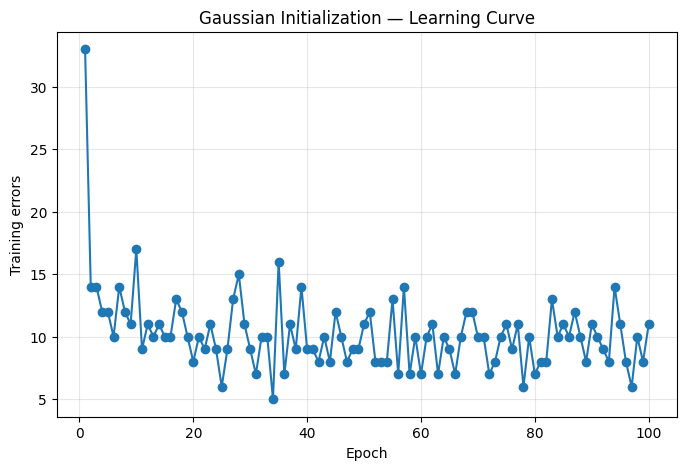

In [9]:
# Task 4 — Gaussian learning curve
plt.figure(figsize=(8,5))
plt.plot(range(1, len(models["gaussian"].errors_)+1),
         models["gaussian"].errors_, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training errors")
plt.title("Gaussian Initialization — Learning Curve")
plt.grid(True, alpha=0.3)
plt.show()


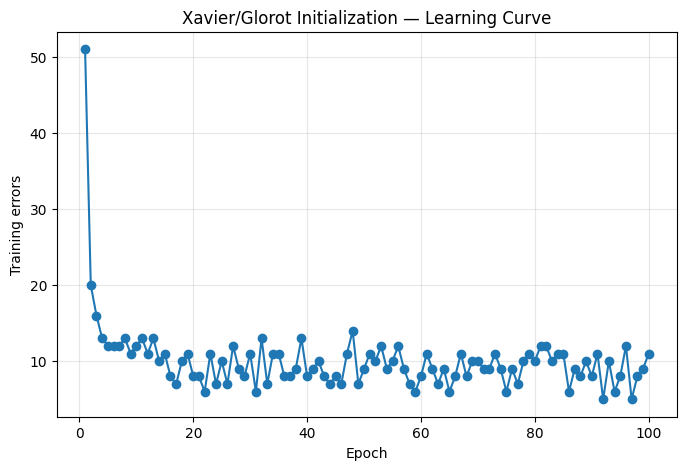

In [10]:
# Task 5 — Xavier learning curve
plt.figure(figsize=(8,5))
plt.plot(range(1, len(models["xavier"].errors_)+1),
         models["xavier"].errors_, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training errors")
plt.title("Xavier/Glorot Initialization — Learning Curve")
plt.grid(True, alpha=0.3)
plt.show()


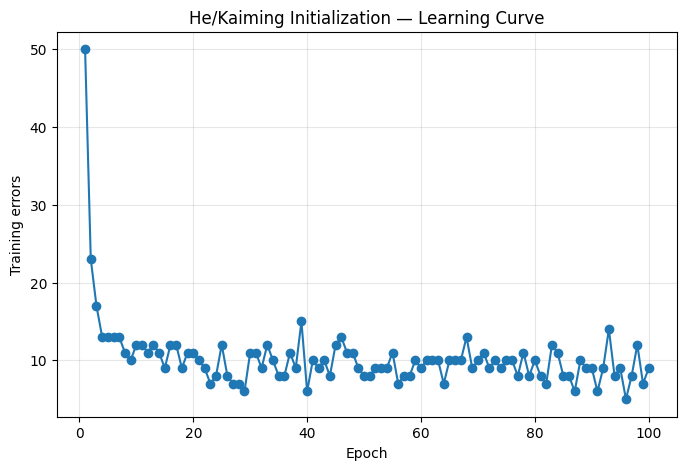

In [11]:
# Task 6 — He learning curve
plt.figure(figsize=(8,5))
plt.plot(range(1, len(models["he"].errors_)+1),
         models["he"].errors_, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training errors")
plt.title("He/Kaiming Initialization — Learning Curve")
plt.grid(True, alpha=0.3)
plt.show()


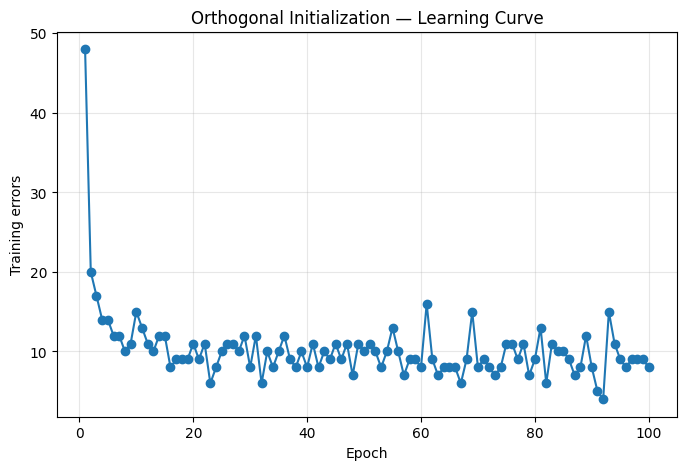

In [12]:
# Task 7 — Orthogonal learning curve
plt.figure(figsize=(8,5))
plt.plot(range(1, len(models["orthogonal"].errors_)+1),
         models["orthogonal"].errors_, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training errors")
plt.title("Orthogonal Initialization — Learning Curve")
plt.grid(True, alpha=0.3)
plt.show()


In [13]:
# Task 8 — Comparative analysis table
rows = []
for method, model in models.items():
    rows.append({
        "Initialization": method.capitalize(),
        "Epochs": model.converged_epoch_,
        "Final Training Error": model.errors_[-1],
        "Test Accuracy": model.score(X_test, y_test_pm),
        "Final Bias": model.b
    })

comparison = pd.DataFrame(rows)
comparison


,Initialization,Epochs,Final Training Error,Test Accuracy,Final Bias
0,Gaussian,100,11,0.938596,-0.04
1,Xavier,100,11,0.956140,-0.03
2,He,100,9,0.964912,-0.02
3,Orthogonal,100,8,0.956140,-0.03


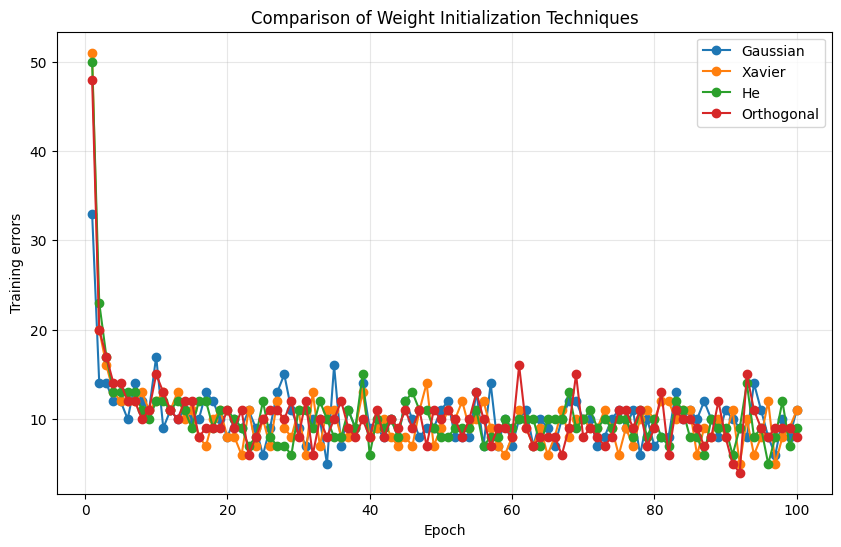

In [14]:
# Task 8 — Plot all learning curves
plt.figure(figsize=(10,6))
for method, model in models.items():
    plt.plot(
        range(1, len(model.errors_)+1),
        model.errors_,
        marker="o",
        label=method.capitalize()
    )

plt.xlabel("Epoch")
plt.ylabel("Training errors")
plt.title("Comparison of Weight Initialization Techniques")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Task 9 — Experimental Study

We run the experiment multiple times with different random seeds. The same binary dataset is used with a **different train/test split** from the earlier experiment. For each initialization, we calculate:

- average convergence epochs
- average test accuracy
- standard deviation of test accuracy

This demonstrates how randomness and dataset splitting can influence perceptron training.


In [15]:
# Task 9 — Different train/test split + multiple random seeds
X9_train, X9_test, y9_train, y9_test = train_test_split(
    data.data, data.target, test_size=0.25, random_state=123, stratify=data.target
)

scaler9 = StandardScaler()
X9_train = scaler9.fit_transform(X9_train)
X9_test = scaler9.transform(X9_test)

y9_train_pm = np.where(y9_train == 0, -1, 1)
y9_test_pm = np.where(y9_test == 0, -1, 1)

seeds = [1, 7, 21, 42, 99]
task9_results = []

for method in methods:
    for seed in seeds:
        model = PerceptronScratch(
            learning_rate=0.01,
            max_epochs=100,
            init_method=method,
            random_state=seed
        )
        model.fit(X9_train, y9_train_pm)

        task9_results.append({
            "Initialization": method.capitalize(),
            "Seed": seed,
            "Convergence Epochs": model.converged_epoch_,
            "Test Accuracy": model.score(X9_test, y9_test_pm),
            "Final Training Error": model.errors_[-1]
        })

task9_df = pd.DataFrame(task9_results)
task9_df


,Initialization,Seed,Convergence Epochs,Test Accuracy,Final Training Error
0,Gaussian,1,100,0.958042,10
1,Gaussian,7,100,0.937063,9
2,Gaussian,21,100,0.972028,10
3,Gaussian,42,100,0.958042,15
4,Gaussian,99,100,0.972028,13
5,Xavier,1,100,0.951049,6
6,Xavier,7,100,0.951049,12
7,Xavier,21,100,0.958042,10
8,Xavier,42,100,0.951049,9
9,Xavier,99,100,0.951049,8


In [16]:
# Task 9 — Average results
task9_summary = (
    task9_df.groupby("Initialization")
    .agg(
        Average_Convergence_Epochs=("Convergence Epochs", "mean"),
        Average_Test_Accuracy=("Test Accuracy", "mean"),
        Std_Test_Accuracy=("Test Accuracy", "std"),
        Average_Final_Training_Error=("Final Training Error", "mean")
    )
    .reset_index()
)

task9_summary


,Initialization,Average_Convergence_Epochs,Average_Test_Accuracy,Std_Test_Accuracy,Average_Final_Training_Error
0,Gaussian,100.0,0.959441,0.014331,11.4
1,He,100.0,0.952448,0.003127,8.0
2,Orthogonal,100.0,0.953846,0.010605,9.6
3,Xavier,100.0,0.952448,0.003127,9.0


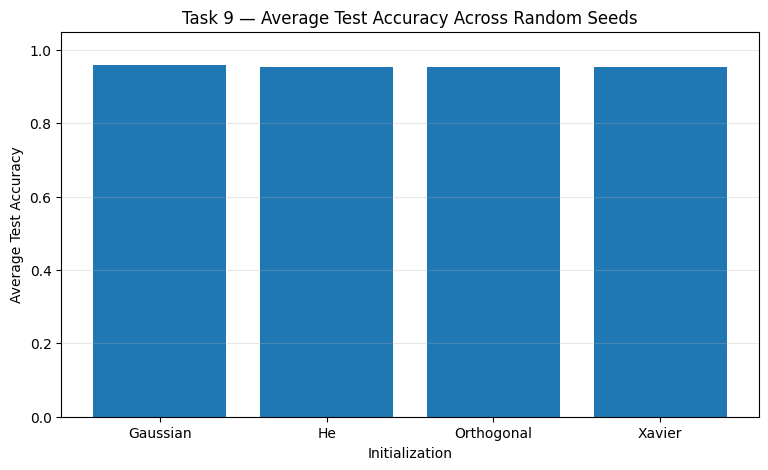

In [17]:
# Task 9 — Plot average test accuracy
plt.figure(figsize=(9,5))
plt.bar(task9_summary["Initialization"], task9_summary["Average_Test_Accuracy"])
plt.xlabel("Initialization")
plt.ylabel("Average Test Accuracy")
plt.title("Task 9 — Average Test Accuracy Across Random Seeds")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.show()


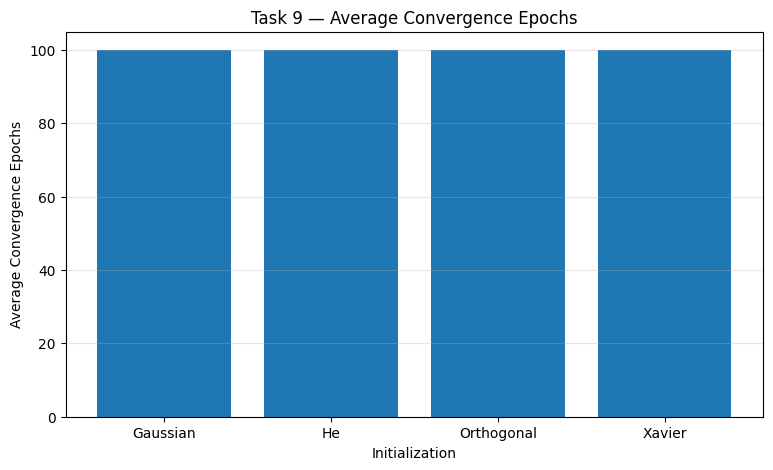

In [18]:
# Task 9 — Plot average convergence epochs
plt.figure(figsize=(9,5))
plt.bar(task9_summary["Initialization"], task9_summary["Average_Convergence_Epochs"])
plt.xlabel("Initialization")
plt.ylabel("Average Convergence Epochs")
plt.title("Task 9 — Average Convergence Epochs")
plt.grid(axis="y", alpha=0.3)
plt.show()
